In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install nuscenes-devkit numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2
!pip install nuscenes-devkit
!pip uninstall -y numpy scipy scikit-learn
!pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2 nuscenes-devkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 60.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 116.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 40.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninst

In [4]:
# 1. Download the mini dataset (this might take a minute or two)
!wget https://www.nuscenes.org/data/v1.0-mini.tgz

# 2. Unzip it into the /content directory
!tar -xf v1.0-mini.tgz -C /content/

# 3. Remove the zip file to save Colab disk space
!rm v1.0-mini.tgz

--2026-03-31 15:30:24--  https://www.nuscenes.org/data/v1.0-mini.tgz
Resolving www.nuscenes.org (www.nuscenes.org)... 13.226.251.15, 13.226.251.24, 13.226.251.71, ...
Connecting to www.nuscenes.org (www.nuscenes.org)|13.226.251.15|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4167696325 (3.9G) [application/x-tar]
Saving to: ‘v1.0-mini.tgz’

v1.0-mini.tgz       100%[===================>]   3.88G   296MB/s    in 13s     

2026-03-31 15:30:38 (298 MB/s) - ‘v1.0-mini.tgz’ saved [4167696325/4167696325]



In [5]:
!pip install nuscenes-devkit numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.480 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.

--- Dataset Loaded Successfully! ---

Rendering Front Camera Image...


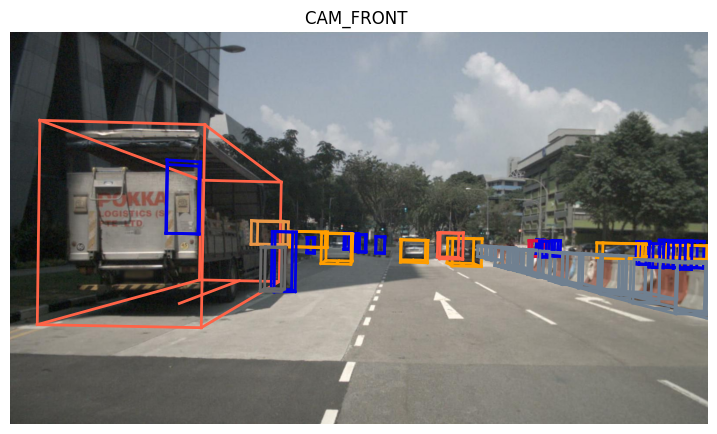

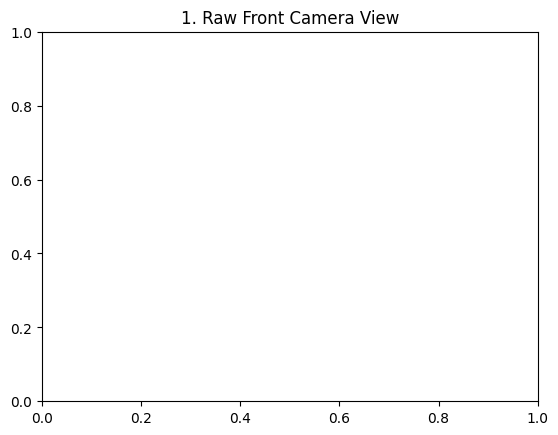


Rendering LiDAR projected onto the camera image...


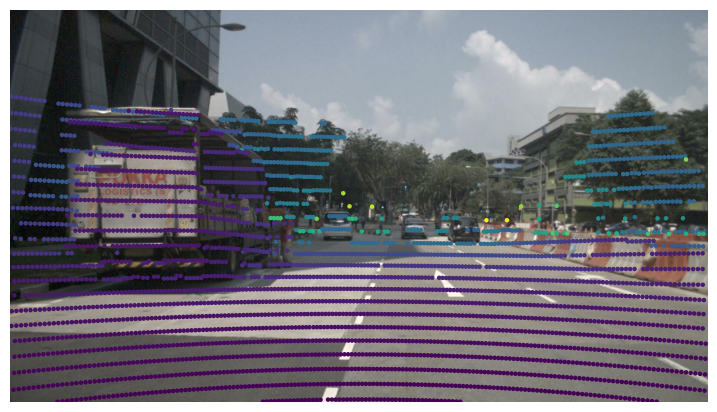

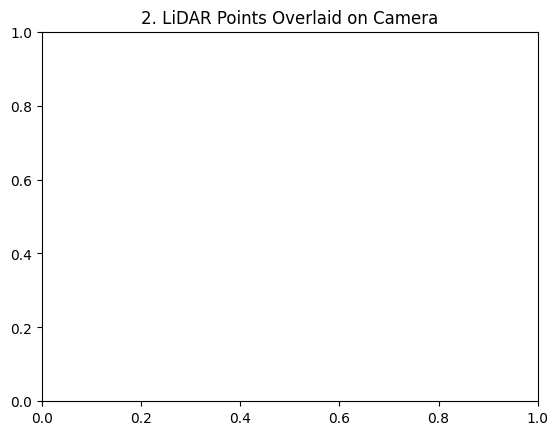

In [7]:
import matplotlib.pyplot as plt
from nuscenes.nuscenes import NuScenes

# IMPORTANT: Since you are in Colab, you need to point this to where 
# you unzipped the dataset in your Colab files or Google Drive.
# Example: '/content/nuscenes-mini/v1.0-mini' or '/content/drive/MyDrive/nuscenes'
DATAROOT = '/content'

try:
    nusc = NuScenes(version='v1.0-mini', dataroot=DATAROOT, verbose=True)
    print("\n--- Dataset Loaded Successfully! ---")
    
    my_scene = nusc.scene[0]
    first_sample_token = my_scene['first_sample_token']
    my_sample = nusc.get('sample', first_sample_token)

    cam_front_token = my_sample['data']['CAM_FRONT']

    print("\nRendering Front Camera Image...")
    nusc.render_sample_data(cam_front_token)
    plt.title("1. Raw Front Camera View")
    plt.show()

    print("\nRendering LiDAR projected onto the camera image...")
    nusc.render_pointcloud_in_image(
        my_sample['token'], 
        pointsensor_channel='LIDAR_TOP', 
        camera_channel='CAM_FRONT'
    )
    plt.title("2. LiDAR Points Overlaid on Camera")
    plt.show()

except Exception as e:
    print(f"Error loading data: {e}")
    print("Double-check that your DATAROOT path points to the unzipped nuScenes folder!")


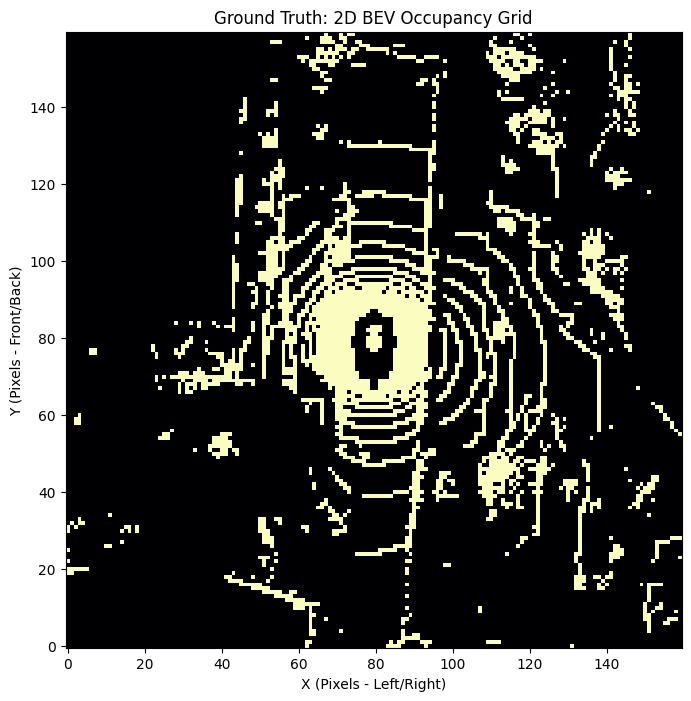

In [9]:
import numpy as np
import os
from nuscenes.utils.data_classes import LidarPointCloud

# 1. Get the LiDAR token and file path for the current sample
lidar_token = my_sample['data']['LIDAR_TOP']
lidar_data = nusc.get('sample_data', lidar_token)
lidar_filepath = os.path.join(nusc.dataroot, lidar_data['filename'])

# 2. Load the 3D point cloud
pc = LidarPointCloud.from_file(lidar_filepath)
points = pc.points # This is a 4xN array containing (X, Y, Z, Intensity)

# 3. Extract just the X and Y coordinates (ignoring Z height for a flat top-down view)
x = points[0, :]
y = points[1, :]

# 4. Define our grid boundaries around the ego-vehicle
# Let's look 40 meters in every direction. The car is at (0,0).
min_x, max_x = -40, 40
min_y, max_y = -40, 40
resolution = 0.5 # Each pixel in our grid will represent a 0.5m x 0.5m physical square

# 5. Filter out points that fall outside our 40m x 40m boundary
mask = (x >= min_x) & (x <= max_x) & (y >= min_y) & (y <= max_y)
x_filtered = x[mask]
y_filtered = y[mask]

# 6. Convert physical coordinates (meters) to grid indices (pixels)
x_img = np.floor((x_filtered - min_x) / resolution).astype(int)
y_img = np.floor((y_filtered - min_y) / resolution).astype(int)

# 7. Create the empty 2D Occupancy Grid
width = int((max_x - min_x) / resolution)
height = int((max_y - min_y) / resolution)
occupancy_grid = np.zeros((height, width))

# 8. Populate the grid: mark a pixel as '1' (Occupied) if a LiDAR point falls inside it
occupancy_grid[y_img, x_img] = 1

# 9. Visualize the Ground Truth BEV map!
plt.figure(figsize=(8, 8))
plt.imshow(occupancy_grid, cmap='magma', origin='lower')
plt.title("Ground Truth: 2D BEV Occupancy Grid")
plt.xlabel("X (Pixels - Left/Right)")
plt.ylabel("Y (Pixels - Front/Back)")
plt.show()

In [10]:
import torch
import torch.nn as nn
import torchvision.models as models

class BEVOccupancyModel(nn.Module):
    def __init__(self, bev_width=80, bev_height=80):
        super(BEVOccupancyModel, self).__init__()
        
        # 1. THE BACKBONE
        weights = models.ResNet18_Weights.DEFAULT
        resnet = models.resnet18(weights=weights)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.feature_compress = nn.Conv2d(512, 64, kernel_size=1)

        # 2. THE LEARNED VIEW TRANSFORMER (The Missing Piece)
        # We flatten the spatial dimensions of the image (14x30) and map them 
        # directly to the spatial dimensions of the BEV grid (80x80).
        self.flatten = nn.Flatten(start_dim=2)
        # ResNet18 outputs 14x30 spatial size. 14*30 = 420. 
        # We want an 80x80 grid. 80*80 = 6400.
        # ResNet18 outputs 7x15 spatial size. 7 * 15 = 105. 
        # We want an 80x80 grid. 80 * 80 = 6400.
        self.spatial_mapper = nn.Linear(105, 6400)

        # 3. THE BEV DECODER
        self.bev_decoder = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, kernel_size=1) 
            # Note: We removed the Sigmoid here because PyTorch's BCEWithLogitsLoss is more stable!
        )

    def forward(self, image):
        # Step 1: Extract 2D features
        features_2d = self.backbone(image)
        features_2d = self.feature_compress(features_2d) # Shape: (B, 64, 14, 30)
        
        # Step 2: Transform Perspective (Image Space -> BEV Space)
        b, c, h, w = features_2d.shape
        flat_features = self.flatten(features_2d) # Shape: (B, 64, 420)
        
        # Map the 420 image pixels to 6400 BEV pixels
        mapped_features = self.spatial_mapper(flat_features) # Shape: (B, 64, 6400)
        
        # Reshape back into a 2D grid
        bev_features = mapped_features.view(b, c, 80, 80) # Shape: (B, 64, 80, 80)
        
        # Step 3: Decode into final occupancy map
        occupancy_prediction = self.bev_decoder(bev_features) # Shape: (Batch, 1, 80, 80)
        
        return occupancy_prediction
# Let's test if the model compiles and runs a dummy image!
if __name__ == "__main__":
    dummy_image = torch.randn(1, 3, 224, 480) # 1 image, 3 color channels, 224x480 resolution
    model = BEVOccupancyModel()
    
    output = model(dummy_image)
    print(f"Input Image Shape: {dummy_image.shape}")
    print(f"Output BEV Grid Shape: {output.shape}") 
    # Expected Output: [1, 1, 80, 80] representing our grid

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s] 


Input Image Shape: torch.Size([1, 3, 224, 480])
Output BEV Grid Shape: torch.Size([1, 1, 80, 80])


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
from nuscenes.utils.data_classes import LidarPointCloud

class NuScenesBEVDataset(Dataset):
    def __init__(self, nusc, scene_tokens, resolution=0.5, map_size=20):
        self.nusc = nusc
        self.resolution = resolution
        self.map_size = map_size # 20 means a 40m x 40m box (-20m to +20m)
        
        # 1. Gather all samples from the provided scenes
        self.sample_tokens = []
        for scene_token in scene_tokens:
            scene = self.nusc.get('scene', scene_token)
            curr_token = scene['first_sample_token']
            while curr_token != '':
                self.sample_tokens.append(curr_token)
                sample = self.nusc.get('sample', curr_token)
                curr_token = sample['next']
        
        # 2. Standard PyTorch Image Transformations
        self.transform = transforms.Compose([
            transforms.Resize((224, 480)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.sample_tokens)

    def __getitem__(self, idx):
        sample = self.nusc.get('sample', self.sample_tokens[idx])
        
        # --- A. LOAD & TRANSFORM IMAGE ---
        cam_data = self.nusc.get('sample_data', sample['data']['CAM_FRONT'])
        img_path = os.path.join(self.nusc.dataroot, cam_data['filename'])
        image = Image.open(img_path).convert('RGB')
        image_tensor = self.transform(image)
        
        # --- B. EXTRACT CAMERA INTRINSICS ---
        calibrated_sensor = self.nusc.get('calibrated_sensor', cam_data['calibrated_sensor_token'])
        intrinsics = torch.tensor(calibrated_sensor['camera_intrinsic'], dtype=torch.float32)
        
        # --- C. GENERATE GROUND TRUTH BEV GRID ---
        lidar_data = self.nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        lidar_path = os.path.join(self.nusc.dataroot, lidar_data['filename'])
        pc = LidarPointCloud.from_file(lidar_path)
        
        x = pc.points[0, :]
        y = pc.points[1, :]
        
        # Filter points within our map boundaries
        mask = (x >= -self.map_size) & (x <= self.map_size) & (y >= -self.map_size) & (y <= self.map_size)
        x_filtered = x[mask]
        y_filtered = y[mask]
        
        # Create empty grid (80x80 if map_size=20 and resolution=0.5)
        grid_dim = int((self.map_size * 2) / self.resolution)
        grid = np.zeros((grid_dim, grid_dim), dtype=np.float32)
        
        # Convert physical coordinates to pixel indices
        x_img = np.floor((x_filtered + self.map_size) / self.resolution).astype(int)
        y_img = np.floor((y_filtered + self.map_size) / self.resolution).astype(int)
        
        # Ensure indices don't go out of bounds, then populate grid
        valid_idx = (x_img >= 0) & (x_img < grid_dim) & (y_img >= 0) & (y_img < grid_dim)
        grid[y_img[valid_idx], x_img[valid_idx]] = 1.0
        
        grid_tensor = torch.tensor(grid).unsqueeze(0) # Shape: (1, 80, 80)
        
        return image_tensor, grid_tensor, intrinsics

# Let's test the Dataset!
if __name__ == "__main__":
    # Grab the first 2 scenes for training
    train_scenes = [s['token'] for s in nusc.scene]
    
    train_dataset = NuScenesBEVDataset(nusc, train_scenes)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    
    # Fetch one batch
    images, gt_grids, intrinsics = next(iter(train_loader))
    
    print(f"Batch Images Shape: {images.shape}")
    print(f"Batch Ground Truth Shape: {gt_grids.shape}")
    print(f"Batch Intrinsics Shape: {intrinsics.shape}")

Batch Images Shape: torch.Size([4, 3, 224, 480])
Batch Ground Truth Shape: torch.Size([4, 1, 80, 80])
Batch Intrinsics Shape: torch.Size([4, 3, 3])


Training on: cuda

--- Starting Training ---
--- Epoch 1/50 Completed | Average Loss: 0.5563 ---
  Accuracy: 0.7279
  F1_Score: 0.5231
  IoU: 0.3566
--- Epoch 2/50 Completed | Average Loss: 0.4619 ---
  Accuracy: 0.7961
  F1_Score: 0.5828
  IoU: 0.4122
--- Epoch 3/50 Completed | Average Loss: 0.4289 ---
  Accuracy: 0.8097
  F1_Score: 0.6224
  IoU: 0.4540
--- Epoch 4/50 Completed | Average Loss: 0.4029 ---
  Accuracy: 0.8211
  F1_Score: 0.6551
  IoU: 0.4900
--- Epoch 5/50 Completed | Average Loss: 0.3791 ---
  Accuracy: 0.8315
  F1_Score: 0.6813
  IoU: 0.5207
--- Epoch 6/50 Completed | Average Loss: 0.3559 ---
  Accuracy: 0.8408
  F1_Score: 0.7041
  IoU: 0.5475
--- Epoch 7/50 Completed | Average Loss: 0.3360 ---
  Accuracy: 0.8492
  F1_Score: 0.7250
  IoU: 0.5727
--- Epoch 8/50 Completed | Average Loss: 0.3159 ---
  Accuracy: 0.8583
  F1_Score: 0.7460
  IoU: 0.5977
--- Epoch 9/50 Completed | Average Loss: 0.2976 ---
  Accuracy: 0.8674
  F1_Score: 0.7660
  IoU: 0.6233
--- Epoch 10/50 Com

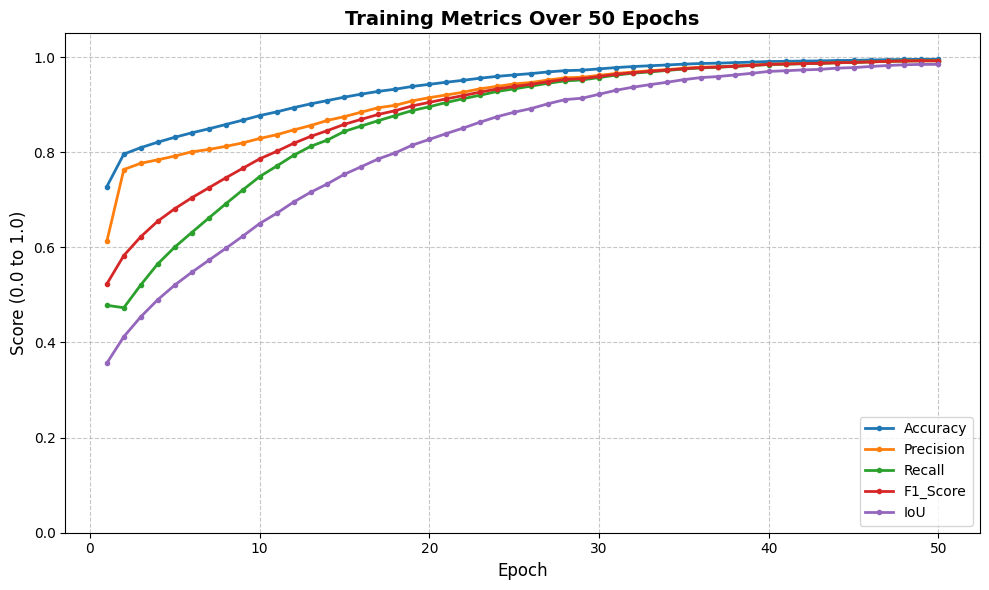

In [13]:
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- 1. Define Metric & Plotting Functions First ---
def calculate_occupancy_metrics(predictions, targets, threshold=0.5, epsilon=1e-7):
    preds_binary = (predictions >= threshold).float()
    targets = targets.float()
    
    TP = (preds_binary * targets).sum()
    FP = (preds_binary * (1 - targets)).sum()
    FN = ((1 - preds_binary) * targets).sum()
    TN = ((1 - preds_binary) * (1 - targets)).sum()
    
    accuracy = (TP + TN) / (TP + TN + FP + FN + epsilon)
    precision = TP / (TP + FP + epsilon)
    recall = TP / (TP + FN + epsilon)
    f1_score = 2 * (precision * recall) / (precision + recall + epsilon)
    iou = TP / (TP + FP + FN + epsilon)
    
    return {
        "Accuracy": accuracy.item(),
        "Precision": precision.item(),
        "Recall": recall.item(),
        "F1_Score": f1_score.item(),
        "IoU": iou.item()
    }

def plot_training_metrics(history, epochs, save_path="training_metrics.png"):
    plt.figure(figsize=(10, 6))
    epochs_range = range(1, epochs + 1)
    
    # Plot everything except Loss on the primary axis (since they are 0-1)
    for metric_name, values in history.items():
        if metric_name != "Loss":
            plt.plot(epochs_range, values, marker='.', linewidth=2, label=metric_name)
            
    plt.title('Training Metrics Over 50 Epochs', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# --- 2. Setup Device, Model, Optimizer, Loss ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model = BEVOccupancyModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss() 

# --- 3. Initialize History Dictionary ---
history = {"Loss": [], "Accuracy": [], "Precision": [], "Recall": [], "F1_Score": [], "IoU": []}

# --- 4. Main Training Loop ---
EPOCHS = 50
print("\n--- Starting Training ---")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    # Track metrics specifically for this epoch
    epoch_metrics = {"Accuracy": 0, "Precision": 0, "Recall": 0, "F1_Score": 0, "IoU": 0}
    
    for i, (images, gt_grids, intrinsics) in enumerate(train_loader):
        # Move data to GPU
        images = images.to(device)
        gt_grids = gt_grids.to(device)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward Pass
        predictions = model(images)
        loss = criterion(predictions, gt_grids)
        
        # Backward Pass & Update Weights
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # --- NEW: Calculate Batch Metrics ---
        # 1. Apply Sigmoid to convert raw logits to probabilities (0 to 1)
        # 2. Use .detach() so we don't store the computation graph
        probs = torch.sigmoid(predictions).detach()
        batch_metrics = calculate_occupancy_metrics(probs, gt_grids)
        
        # Add batch metrics to the epoch totals
        for k in epoch_metrics.keys():
            epoch_metrics[k] += batch_metrics[k]
            
    # --- End of Epoch Processing ---
    num_batches = len(train_loader)
    avg_loss = running_loss / num_batches
    history["Loss"].append(avg_loss)
    
    print(f"--- Epoch {epoch+1}/{EPOCHS} Completed | Average Loss: {avg_loss:.4f} ---")
    
    # Average the metrics over all batches and save to history
    for k in epoch_metrics.keys():
        avg_metric = epoch_metrics[k] / num_batches
        history[k].append(avg_metric)
        # Print a few key metrics to the console so you can watch it learn
        if k in ["IoU", "F1_Score", "Accuracy"]:
            print(f"  {k}: {avg_metric:.4f}")

print("\nTraining Complete!")

# --- 5. Generate the Plot ---
plot_training_metrics(history, EPOCHS)

Running Inference...

--- Metrics ---
Batch Mean Occupancy IoU: 0.9879 (Higher is better)


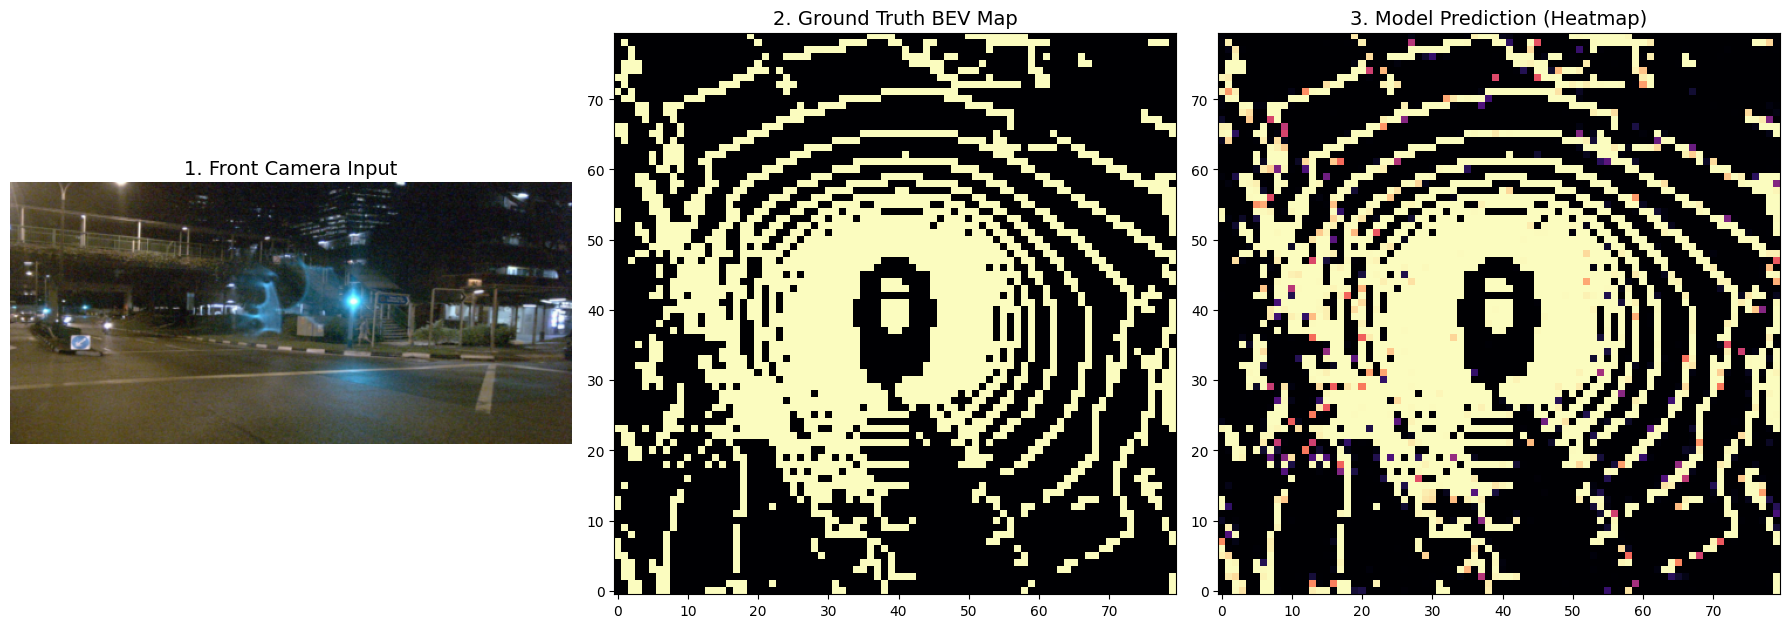

In [14]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. Put model in evaluation mode (turns off dropout/batchnorm updates)
model.eval()

# 2. Grab a fresh batch of data
images, gt_grids, intrinsics = next(iter(train_loader))
images = images.to(device)

print("Running Inference...")

# 3. Forward Pass (No gradients needed for testing)
with torch.no_grad():
    raw_logits = model(images)
    # Because we removed the Sigmoid layer earlier for stable training, 
    # we must apply it now to convert the raw numbers into probabilities (0 to 1)
    predictions = torch.sigmoid(raw_logits)

# 4. Move data back to CPU for Matplotlib visualization
images = images.cpu()
gt_grids = gt_grids.cpu().squeeze(1) # Shape: (Batch, 80, 80)
predictions = predictions.cpu().squeeze(1)

# 5. Calculate Occupancy IoU (Intersection over Union)
# We threshold the prediction at 50% confidence (0.5)
pred_binary = (predictions > 0.5).float()

intersection = (pred_binary * gt_grids).sum(dim=(1, 2))
union = pred_binary.sum(dim=(1, 2)) + gt_grids.sum(dim=(1, 2)) - intersection
iou = (intersection + 1e-6) / (union + 1e-6) # 1e-6 prevents division by zero
mean_iou = iou.mean().item()

print(f"\n--- Metrics ---")
print(f"Batch Mean Occupancy IoU: {mean_iou:.4f} (Higher is better)")

# 6. Prepare the image for visualization (Un-normalize it)
idx = 0 # We will visualize the first image in the batch
img_vis = images[idx].permute(1, 2, 0).numpy() # (C,H,W) to (H,W,C)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_vis = std * img_vis + mean
img_vis = np.clip(img_vis, 0, 1)

# 7. Plotting! (Screenshot this for your PPT)
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_vis)
plt.title("1. Front Camera Input", fontsize=14)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gt_grids[idx].numpy(), cmap='magma', origin='lower')
plt.title("2. Ground Truth BEV Map", fontsize=14)

plt.subplot(1, 3, 3)
plt.imshow(predictions[idx].numpy(), cmap='magma', origin='lower')
plt.title("3. Model Prediction (Heatmap)", fontsize=14)

plt.tight_layout()
plt.show()

In [15]:
import torch

# 1. Define the file name
model_filename = 'bev_occupancy_model.pth'

# 2. Save the model's learned weights (state_dict)
torch.save(model.state_dict(), model_filename)
print(f"Model weights saved successfully to {model_filename}")


Model weights saved successfully to bev_occupancy_model.pth


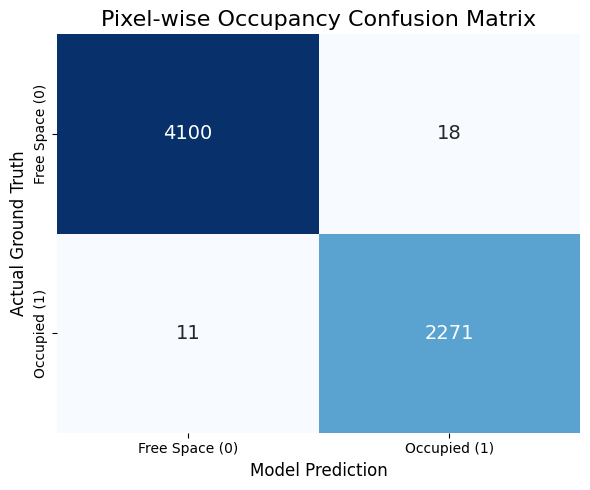

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Flatten the 80x80 grids into 1D arrays
# We use the prediction and ground truth from the previous inference step
y_true = gt_grids[idx].numpy().flatten()
y_pred = pred_binary[idx].numpy().flatten()

# 2. Calculate the Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# 3. Plotting the Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Free Space (0)', 'Occupied (1)'],
            yticklabels=['Free Space (0)', 'Occupied (1)'],
            annot_kws={"size": 14})

plt.title('Pixel-wise Occupancy Confusion Matrix', fontsize=16)
plt.ylabel('Actual Ground Truth', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
import torch

def calculate_occupancy_metrics(predictions, targets, threshold=0.5, epsilon=1e-7):

    # Convert probabilities to binary predictions (0 or 1)
    preds_binary = (predictions >= threshold).float()
    
    # Ensure targets are float for calculation
    targets = targets.float()
    
    # Calculate True Positives, False Positives, True Negatives, False Negatives
    # Summing over all dimensions (batch, channel, height, width)
    TP = (preds_binary * targets).sum()
    FP = (preds_binary * (1 - targets)).sum()
    FN = ((1 - preds_binary) * targets).sum()
    TN = ((1 - preds_binary) * (1 - targets)).sum()
    
    # Calculate Metrics
    accuracy = (TP + TN) / (TP + TN + FP + FN + epsilon)
    precision = TP / (TP + FP + epsilon)
    recall = TP / (TP + FN + epsilon)
    f1_score = 2 * (precision * recall) / (precision + recall + epsilon)
    
    # Intersection over Union (IoU) specifically for the "Occupied" class
    iou = TP / (TP + FP + FN + epsilon)
    
    return {
        "Accuracy": accuracy.item(),
        "Precision": precision.item(),
        "Recall": recall.item(),
        "F1_Score": f1_score.item(),
        "IoU": iou.item()
    }

# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    # Simulating a batch of 4 outputs for your 80x80 grid
    batch_size = 4
    
    # Dummy predictions (e.g., output of a Sigmoid activation layer)
    dummy_preds = torch.rand((batch_size, 1, 80, 80))
    
    # Dummy ground truth (binary LiDAR projection)
    dummy_targets = torch.randint(0, 2, (batch_size, 1, 80, 80)).float()
    
    # Run the evaluation
    metrics = calculate_occupancy_metrics(dummy_preds, dummy_targets)
    
    print("--- Batch Evaluation Metrics ---")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

--- Batch Evaluation Metrics ---
Accuracy: 0.5025
Precision: 0.5045
Recall: 0.5064
F1_Score: 0.5055
IoU: 0.3382
